In [3]:
%load_ext autoreload
%autoreload 2

# 量子传感仿真平台测试
本笔记演示利用仿真平台进行各种量子传感协议

## test1: Rabi振荡


qubit state before evolution: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]


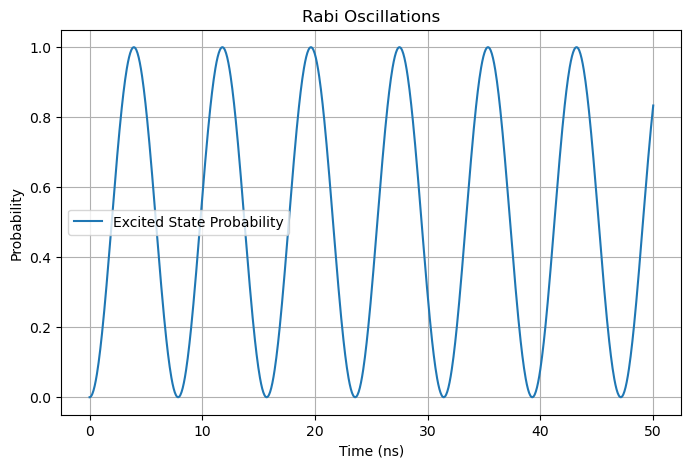

In [4]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,  
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

# 总仿真时长
t_list = np.linspace(0, 50, 1000)  # ns

# 创建Protocal对象，设置测量协议和参数
protocal = Protocal(
    type = 0,
    params = {
        't_list': t_list,
    }
)

# 运行测量协议
protocal.initialize(qubit,state = 0)

print(f"qubit state before evolution: {qubit.state}")

results = protocal.evolve(qubit)

# 分析结果
analysis = Analysis()

p_e = analysis.get_expectation_values(results, e_ops_index = 0)

# 绘制结果
plt.figure(figsize=(8, 5))
plt.plot(t_list, p_e, label='Excited State Probability')
plt.xlabel('Time (ns)')
plt.ylabel('Probability')
plt.title('Rabi Oscillations')
plt.legend()
plt.grid()
plt.show()



## test2: Ramsey 干涉
- 需要完善：无法模拟非恒定信号的情况，如包络是高斯函数时

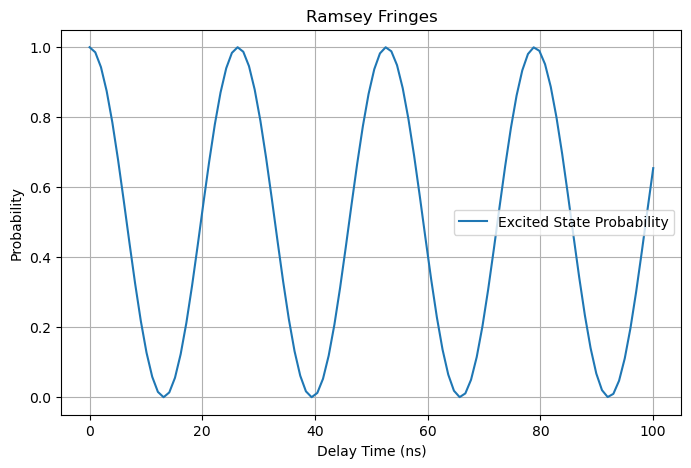

In [5]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

# 总仿真时长

protocal = Protocal(1)

protocal.initialize(qubit,state = 0)

results = protocal.evolve(qubit)



plt.figure(figsize=(8, 5))
plt.plot(protocal.params['tau_list'], results, label='Excited State Probability')
plt.xlabel('Delay Time (ns)')
plt.ylabel('Probability')
plt.title('Ramsey Fringes')
plt.legend()
plt.grid()
plt.show()


# test3: Ramsey干涉（加磁场）


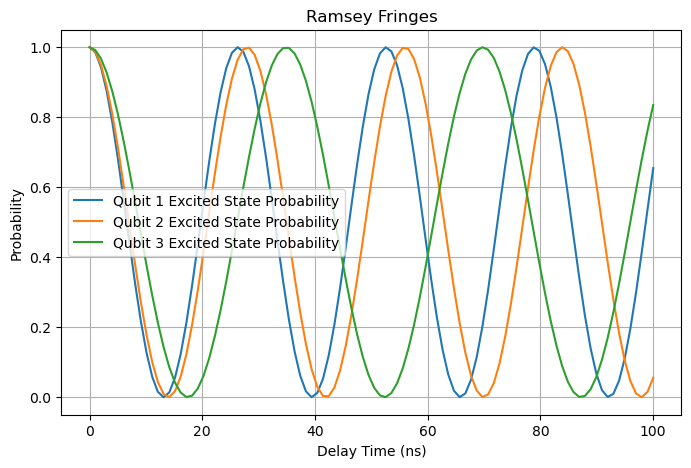

In [6]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubits = []
qubits.append(TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
))

qubits.append(TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.15,
    state = 0,
    n_levels = 2
))
qubits.append(TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.3,
    state = 0,
    n_levels = 2
))

# 总仿真时长

protocal = Protocal(1)

results = []
for i in range(3):
    protocal.initialize(qubits[i],state = 0)
    results.append(protocal.evolve(qubits[i]))



plt.figure(figsize=(8, 5))
for i in range(3):
    plt.plot(protocal.params['tau_list'], results[i], label=f'Qubit {i+1} Excited State Probability')
plt.xlabel('Delay Time (ns)')
plt.ylabel('Probability')
plt.title('Ramsey Fringes')
plt.legend()
plt.grid()
plt.show()


## test4: 密度矩阵模拟求核函数
- stim脉冲的幅值不能太大（导致相位超过$2\pi$），也不能太小（小于脉冲信号幅值）
- 可以增加采样率以减少毛刺
- 由于stim脉冲并未理想delta函数，需要对核函数进行标准化（除以高斯函数面积），标准化后的核函数幅值不一定为1，且标准化后的核函数才可以用于准确还原磁场信号

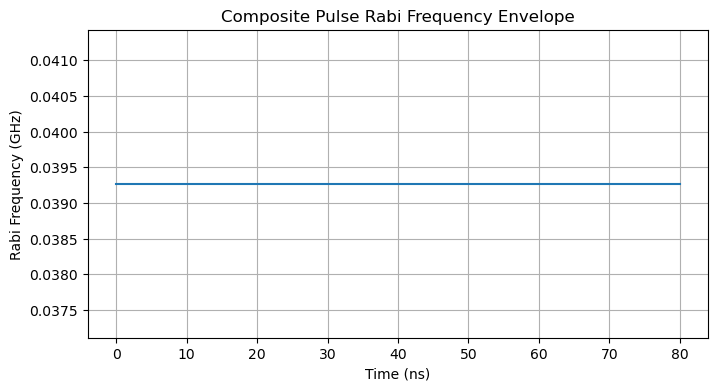

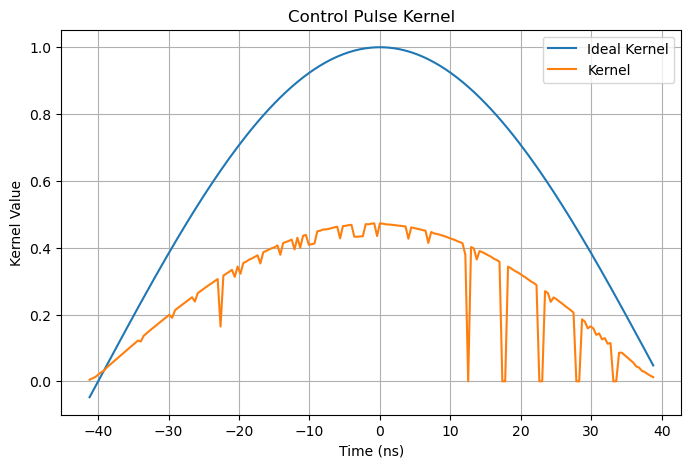

In [13]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

t_rabi = np.linspace(0, 40, 100)
control_pulse = create_ramsey_pulse(t_rabi, tau = 0.0, omega_d = qubit.frequency)


Analysis = Analysis()

t_samples, kernel = Analysis.get_kernel(control_pulse, qubit)
max_index = np.argmax(kernel)
max_kernel = kernel[max_index]
t_max = t_samples[max_index]
t_roll = t_samples - t_max
control_pulse.plot()
kernel_id = [np.sin((np.pi / (2 * t_rabi[-1]))*(t_rabi[-1]-t)) for t in t_roll]
plt.figure(figsize=(8, 5))
plt.plot(t_roll,kernel_id, label='Ideal Kernel')
plt.plot(t_roll, kernel, label='Kernel')
plt.xlabel('Time (ns)')
plt.ylabel('Kernel Value')
plt.title('Control Pulse Kernel')
plt.legend()
plt.grid()
plt.show()

## test5: 瞬态磁场传感协议

注意EC和EJ的单位是rad GHz，T1和T2的单位是ns，频率的单位是GHz，时间的单位是ns。

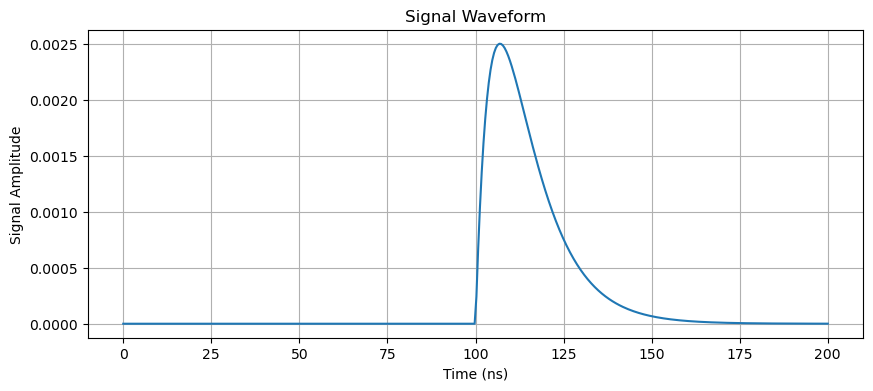

t_samples: 40 ,scan_list: 439
B: [ 4.00864307e-07  5.15503467e-07  6.08806475e-07  6.75295615e-07
  7.10419932e-07  7.10890461e-07  6.74950754e-07  6.02577189e-07
  4.95598191e-07  3.57699730e-07  1.94363413e-07  1.26875357e-08
 -1.78896478e-07 -3.70959687e-07 -5.53529950e-07 -7.16552049e-07
 -8.50418728e-07 -9.46489751e-07 -9.97600109e-07 -9.98522381e-07
 -9.46350719e-07 -8.40805597e-07 -6.84405720e-07 -4.82494502e-07
 -2.43148172e-07  2.30845347e-08  3.03589256e-07  5.84234004e-07
  8.50011866e-07  1.08579048e-06  1.27712056e-06  1.41104005e-06
  1.47686413e-06  1.46689989e-06  1.37705411e-06  1.20727105e-06
  9.61792642e-07  6.49201213e-07  2.82231422e-07 -1.22653995e-07
 -5.45916045e-07 -9.65798749e-07 -1.35936268e-06 -1.70364811e-06
 -1.97691301e-06 -2.15988424e-06 -2.23695521e-06 -2.19726220e-06
 -2.03557362e-06 -1.75293238e-06 -1.35700124e-06 -8.62073400e-07
 -2.88726345e-07  3.36885558e-07  9.84085331e-07  1.61904070e-06
  2.20639178e-06  2.71106914e-06  3.10021726e-06  3.34512

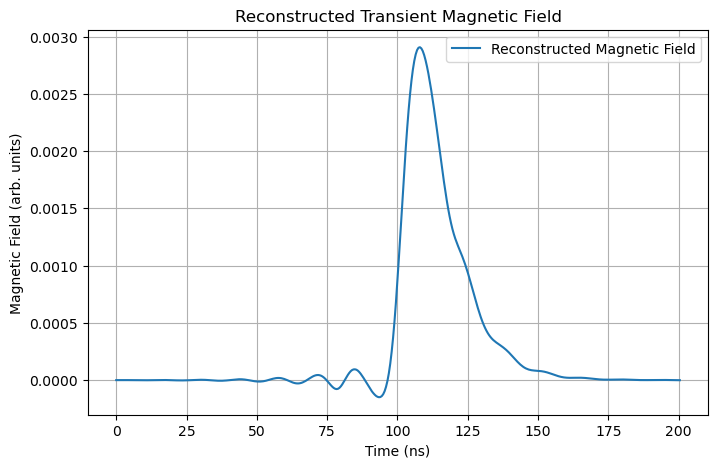

In [25]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)

protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results = protocal.evolve(qubit)
analysis = Analysis()
kernel_id = [np.sin((np.pi / (2 * (scan_list[-1]-scan_list[0])))*(scan_list[-1]-t)) for t in t_samples]
print(f"t_samples: {len(t_samples)} ,scan_list: {len(scan_list)}")
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.wiener_deconvolution(results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')
plt.figure(figsize=(8, 5))
#plt.plot(scan_list, results, label='Measured Excited State Probability')
plt.plot(B_lists, B, label='Reconstructed Magnetic Field')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()


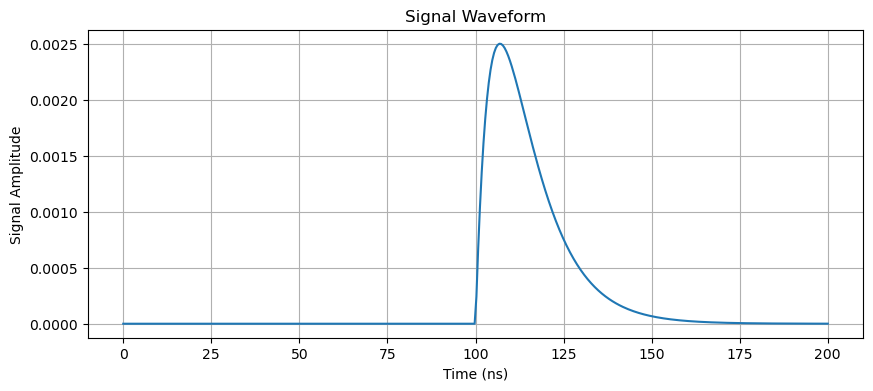

t_samples: 40 ,scan_list: 439


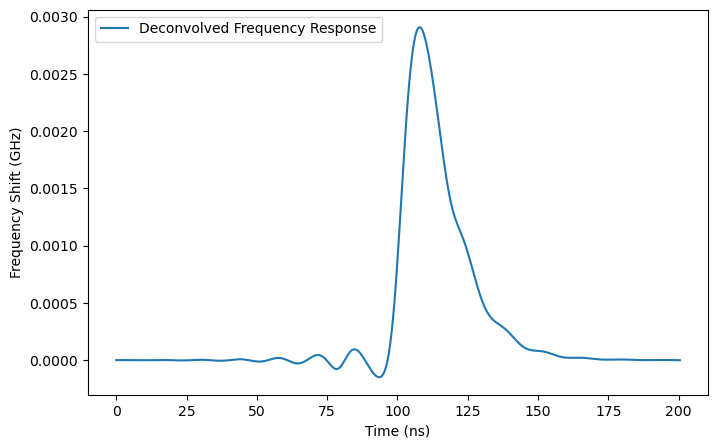

B: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan

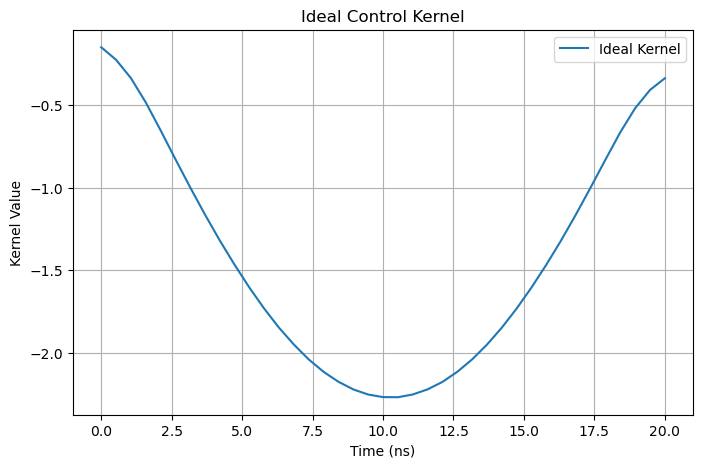

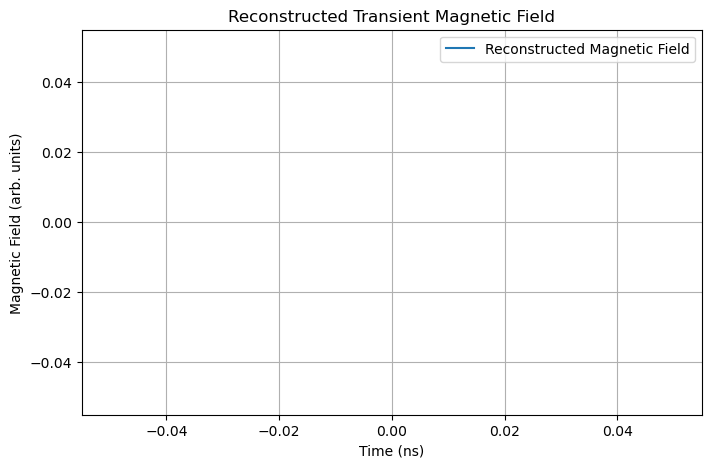

In [4]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)

protocal = Protocal(4)
protocal.initialize(qubit,state = 0)
t_samples, kernel, scan_list, results = protocal.evolve(qubit)
analysis = Analysis()
kernel_id = [np.sin((np.pi / (2 * (scan_list[-1]-scan_list[0])))*(scan_list[-1]-t)) for t in t_samples]
print(f"t_samples: {len(t_samples)} ,scan_list: {len(scan_list)}")
dt = scan_list[1] - scan_list[0]
B_lists, B = analysis.hammerstein_wiener_deconvolution(qubit, results, kernel, dt, lambdas = 5.0)
print(f'B: {B}')

plt.figure(figsize=(8, 5))
plt.plot(t_samples, kernel, label='Ideal Kernel')
plt.xlabel('Time (ns)')
plt.ylabel('Kernel Value')
plt.title('Ideal Control Kernel')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
#plt.plot(scan_list, results, label='Measured Excited State Probability')
plt.plot(B_lists, B, label='Reconstructed Magnetic Field')
plt.xlabel('Time (ns)')
plt.ylabel('Magnetic Field (arb. units)')
plt.title('Reconstructed Transient Magnetic Field')
plt.legend()
plt.grid()
plt.show()


In [10]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from qutip import mesolve, basis
from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

qubit0 = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0,
    state = 0,
    n_levels = 2
)
# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.1,
    state = 0,
    n_levels = 2
)
psi_e = basis(qubit.n_levels, 1)
H_0 = qubit.get_hamiltonian_rwa(qubit0.frequency)
t_rabi = np.linspace(0, 5, 100)
composite_pulse = create_ramsey_pulse(t_rabi, tau = 0.0, omega_d = qubit0.frequency)
H_t = lambda t: H_0 + composite_pulse.get_hamiltonian(t)
result = mesolve(H_t, qubit.state, composite_pulse.t_list, [], e_ops=[psi_e * psi_e.dag()])
p_e = result.expect[0]

print(f"Final excited state probability: {p_e[-1]}")

Final excited state probability: 0.19700147770922893


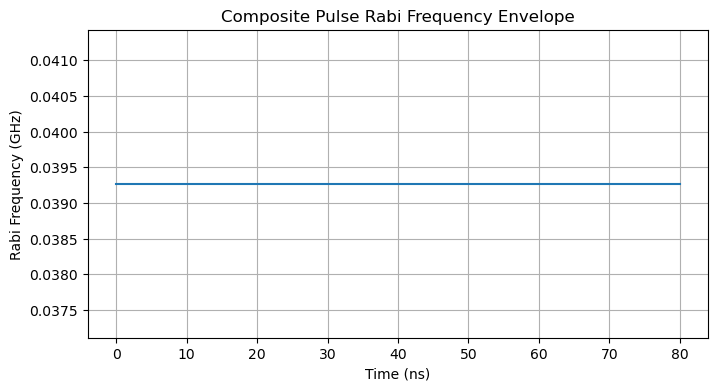

B: (array([ 0.        ,  0.4040404 ,  0.80808081,  1.21212121,  1.61616162,
        2.02020202,  2.42424242,  2.82828283,  3.23232323,  3.63636364,
        4.04040404,  4.44444444,  4.84848485,  5.25252525,  5.65656566,
        6.06060606,  6.46464646,  6.86868687,  7.27272727,  7.67676768,
        8.08080808,  8.48484848,  8.88888889,  9.29292929,  9.6969697 ,
       10.1010101 , 10.50505051, 10.90909091, 11.31313131, 11.71717172,
       12.12121212, 12.52525253, 12.92929293, 13.33333333, 13.73737374,
       14.14141414, 14.54545455, 14.94949495, 15.35353535, 15.75757576,
       16.16161616, 16.56565657, 16.96969697, 17.37373737, 17.77777778,
       18.18181818, 18.58585859, 18.98989899, 19.39393939, 19.7979798 ,
       20.2020202 , 20.60606061, 21.01010101, 21.41414141, 21.81818182,
       22.22222222, 22.62626263, 23.03030303, 23.43434343, 23.83838384,
       24.24242424, 24.64646465, 25.05050505, 25.45454545, 25.85858586,
       26.26262626, 26.66666667, 27.07070707, 27.47474747, 2

ValueError: x and y must have same first dimension, but have shapes (100,) and (2, 100)

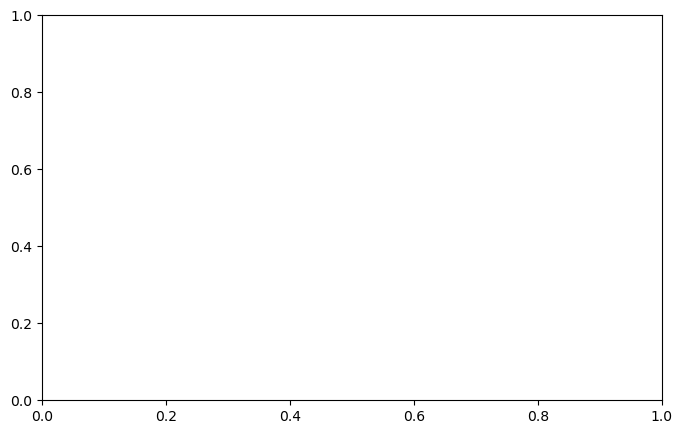

In [11]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

t_rabi = np.linspace(0, 40, 100)
control_pulse = create_ramsey_pulse(t_rabi, tau = 0.0, omega_d = qubit.frequency)


Analysis = Analysis()

t_samples, kernel = Analysis.get_kernel(control_pulse, qubit)
max_index = np.argmax(kernel)
max_kernel = kernel[max_index]
kernel_roll = np.roll(kernel, -max_index)
t_max = t_samples[max_index]
t_shift = t_samples - t_max
t_roll = np.roll(t_shift, -max_index)

control_pulse.plot()
kernel_id = [np.sin((np.pi / (2 * t_rabi[-1]))*(t_rabi[-1]-t)) for t in t_shift]

t_Phi = np.linspace(0, 160, 100)
Phi = Signal(type = 2, t_list = t_Phi)
Phi_list = [Phi.value_at(t) for t in t_Phi]
dt = t_samples[1] - t_samples[0]

delta_p = dt * np.convolve(kernel, Phi_list, mode='full')  # 模拟等效时间采样测量结果，长度为A+B-1 

B = Analysis.wiener_deconvolution(delta_p, kernel, dt, lambdas = 0.0)

print(f'B: {B}')
#delta_p_new = np.convolve(kernel, B, mode='full')  # 用重建的B重新卷积得到测量结果 


plt.figure(figsize=(8, 5))
#plt.plot(t_Phi, Phi_list, label='Phi Signal')
plt.plot(t_Phi, B, label='Reconstructed B Field')
plt.xlabel('Time (ns)')
plt.ylabel('B Field (arb. units)')
plt.title('Reconstructed B Field from Control Pulse Kernel')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t_samples,kernel_id, label='Ideal Kernel')
plt.plot(t_samples, kernel, label='Kernel')
plt.xlabel('Time (ns)')
plt.ylabel('Kernel Value')
plt.title('Control Pulse Kernel')
plt.legend()
plt.grid()
plt.show()

# TODO
- 完善瞬态磁场协议，增加灵敏度
    - 幅度问题：kernel，反卷积，信号项的系数（响应函数） [参考内容](https://arena.ai/c/019cf09a-0e16-784f-a01f-e8143027d668)
        - 解决：调整stim_pulse 幅度，lambda，使用非线性响应
    - 二阶响应：get_kernel函数和wiener_deconvolution函数中都默认了线性响应，扩展支持二阶响应[参考1](https://arena.ai/c/019d05bf-7b8a-7b86-bed0-a2ecc7924267)[参考2](idea/nonlinear_response_extension.md)
- 增加更多协议，如spin echo, dynamical decoupling，PEA等 
    - PEA[参考内容](https://arena.ai/c/019cf6b6-2699-796c-b5be-7717b7a9082b)
    - 基于微分的传感协议[参考1](https://arena.ai/c/019cf6b6-2699-796c-b5be-7717b7a9082b)[参考2](https://arena.ai/c/019d058c-0104-75ba-b70b-b9dac257dfcf)[参考3](https://arena.ai/c/019d058b-7ccd-7b38-98f7-32e97af73ae9)[参考4](idea/differential_sensing_scheme.md)
- 增加实际情况的模拟，如噪声、非理想脉冲等
- 完善demo，增加交互性
- 撰写README.md
- 实验室实习 [参考内容](https://arena.ai/c/019cf0a9-ca57-7e1e-bdd9-b0d7ea303a19)

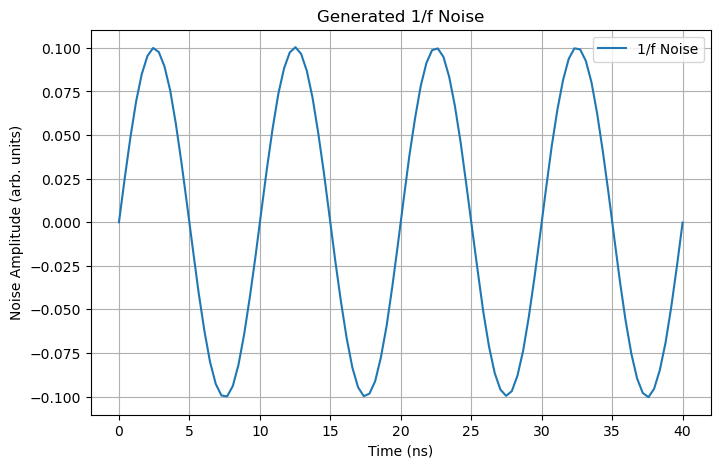

In [ ]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse, CompositePulse, create_ramsey_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

t_rabi = np.linspace(0, 40, 100)
Phi = Signal(type = 2, t_list = t_rabi, amplitude = 0.1)
noise = qubit.generate_1f_noise(t_rabi, amplitude=0.001, f_min=1e-3, f_max=1e3)
plt.figure(figsize=(8, 5))
plt.plot(t_rabi, noise+Phi.signal, label='1/f Noise')
#plt.ylim(0.1-0.01, 0.1+0.01)
plt.xlabel('Time (ns)')
plt.ylabel('Noise Amplitude (arb. units)')
plt.title('Generated 1/f Noise')
plt.legend()
plt.grid()
plt.show()


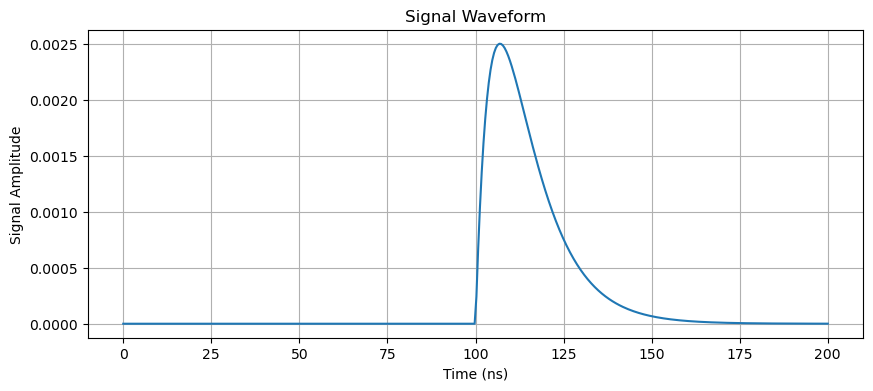

B: nan 


C:\Users\21034\AppData\Local\Temp\ipykernel_61388\3468172686.py:32: RuntimeWarning: invalid value encountered in arccos
  B = (1 / np.pi) * np.arccos((0.000001 + qubit.frequency + qubit.EC) ** 2 / (8 * qubit.EC * qubit.EJ))  # 根据Transmon的频率-磁场关系，得到磁场响应


"\nplt.figure(figsize=(8, 5))\nplt.plot(t_rabi, B, label='B Field from Phi')\nplt.xlabel('Time (ns)') \nplt.ylabel('B Field (arb. units)')\nplt.title('B Field from Phi Signal')\nplt.grid()\nplt.show()\n"

In [24]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 添加src目录到Python路径
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('./src'))

from src.qubit import TransmonQubit
from src.signal import Signal
from src.pulse import Pulse, create_pulse
from src.protocal import Protocal
from src.analysis import Analysis

# 创建qubit对象
qubit = TransmonQubit(
    EC = 0.2 * 2 * np.pi,
    EJ = 10.0 * 2 * np.pi,
    T1 = 100.0e3,   # 100 mu s
    T2 = 50.0e3,    # 50 mu s
    flux = 0.0,
    state = 0,
    n_levels = 2
)

Phi = qubit.optimal_work_point()
qubit.change_flux(Phi)
t_rabi =  np.linspace(0, 200, 400)
Phi = Signal(type = 4, t_list = np.linspace(0, 200, 400), amplitude = 0.01, rise = 10, fall = 10, center = 100)
Phi.plot()
B = (1 / np.pi) * np.arccos((0.000001 + qubit.frequency + qubit.EC) ** 2 / (8 * qubit.EC * qubit.EJ))  # 根据Transmon的频率-磁场关系，得到磁场响应
print(f'B: {B} ')
'''
plt.figure(figsize=(8, 5))
plt.plot(t_rabi, B, label='B Field from Phi')
plt.xlabel('Time (ns)') 
plt.ylabel('B Field (arb. units)')
plt.title('B Field from Phi Signal')
plt.grid()
plt.show()
'''